## load library yang di perlukan dlu

In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## cek gpu cuda

In [2]:
import torch
print("Versi Torch:", torch.__version__)
print("Versi CUDA di Torch:", torch.version.cuda)
print("CUDA tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versi Torch: 2.10.0+cu130
Versi CUDA di Torch: 13.0
CUDA tersedia: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## konfigurasi path

In [3]:
TRAIN_DIR = '../dataset/train'
VAL_DIR = '../dataset/val'
TEST_DIR = '../dataset/test'

MODEL_SAVE_PATH = 'best_model.pth'
CLASS_NAMES_PATH = 'class_names.json'

BATCH_SIZE = 32
EPOCH = 10
LEARNIG_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Di train menggunakan {DEVICE}")

Di train menggunakan cuda


## data preprocessing dan augmentasi

In [4]:
# untuk train di augmented dan di rotasi acek supaya model lebih bagus
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# untuk val test ga augmented, biat pake data ori
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## setelah kita buat augmentasi dan preprosecing kita bakalan load dataset kita, masukkan ke augmentasi kita tadi

In [5]:
print("loading datasets")
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# kita siapkan class names dalam json untuk du pakai be fast api kita nnatinya
class_names = train_dataset.classes
with open(CLASS_NAMES_PATH, 'w') as f:
    json.dump(class_names, f)
print(f"tersimpan {len(class_names)}, kelas di {CLASS_NAMES_PATH}")


loading datasets
tersimpan 10, kelas di class_names.json


## buat dataloader

In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader =DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

## setup arsitektur CNN dan Model MobileNetv3

In [7]:
print("setup model mobilenetv2...")
weghts = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weghts)

#Ubah layer klasifikasi terakhir sesuai jumlah kelas penyakit
num_filter = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_filter, len(class_names))

model = model.to(DEVICE)

# lodd dan optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNIG_RATE)


setup model mobilenetv2...


## trainin loop

In [9]:
best_val_acc = 0.0
for epoch in range(EPOCH):
    print(f"\n epoch {epoch+1}/{EPOCH}")
    print("-" * 15)

    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in tqdm(train_loader, desc="training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    print(f"train loss {epoch_loss:.4f} acc : {epoch_loss:.4f}")

    #val

    model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="validation"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds== labels.data)
    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects.double() / len(val_dataset)
    print(f"val loss : {val_epoch_loss:.4f} acc : {val_epoch_acc:.4} ")

    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("akurasi validasi naik dan best model path nya di perbarui")


 epoch 1/10
---------------


training: 100%|██████████| 261/261 [01:18<00:00,  3.35it/s]


train loss 0.1413 acc : 0.1413


validation: 100%|██████████| 33/33 [00:06<00:00,  5.38it/s]


val loss : 0.1753 acc : 0.9481 
akurasi validasi naik dan best model path nya di perbarui

 epoch 2/10
---------------


...

val loss : 0.1999 acc : 0.9443 

 epoch 10/10
---------------


training: 100%|██████████| 261/261 [01:26<00:00,  3.01it/s]


train loss 0.0749 acc : 0.0749


validation: 100%|██████████| 33/33 [00:08<00:00,  4.06it/s]


val loss : 0.1601 acc : 0.9616 
akurasi validasi naik dan best model path nya di perbarui


## visualisai


 test model terakhir


 testing : 100%|██████████| 33/33 [00:06<00:00,  5.12it/s]



 hasil f1 report data test
                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.96      0.98      0.97        48
   bacterial_leaf_streak       0.97      0.89      0.93        38
bacterial_panicle_blight       1.00      0.94      0.97        34
                   blast       0.97      0.96      0.97       174
              brown_spot       0.94      0.95      0.94        97
              dead_heart       0.96      0.99      0.98       144
            downy_mildew       0.96      0.89      0.92        62
                   hispa       0.94      0.96      0.95       159
                  normal       0.98      0.97      0.98       176
                  tungro       0.95      0.98      0.96       109

                accuracy                           0.96      1041
               macro avg       0.96      0.95      0.96      1041
            weighted avg       0.96      0.96      0.96      1041


 selesai, grafik disimpan di dengan nama con

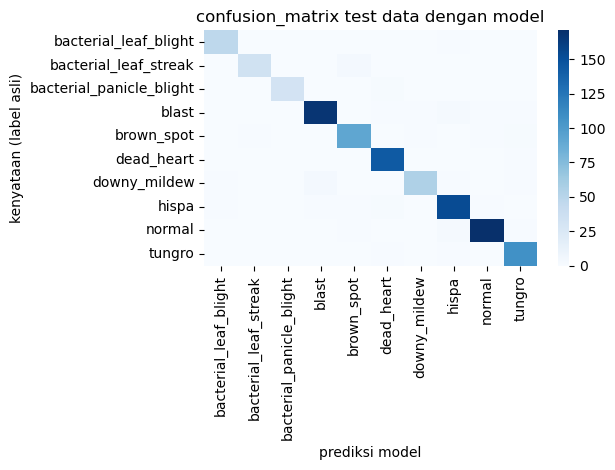

In [15]:
print("\n test model terakhir")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc=" testing "):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

## f1 score report
print("\n hasil f1 report data test")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

# confusion matrixt
cm = confusion_matrix(all_labels, all_preds)
plt.Figure(figsize=(15, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("confusion_matrix test data dengan model")
plt.xlabel("prediksi model")
plt.ylabel("kenyataan (label asli)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('confusion_matrix_padi_model.png')
print("\n selesai, grafik disimpan di dengan nama confussion_matrix_padi_model.png")
